# Eksperimen Hyperparameter Tuning

Notebook akan menguji beberapa komponen berikut:
1. pengaruh depth dan width
2. pengaruh fungsi aktivasi
3. pengaruh learning rate

Dari setiap komponen pengujian akan dibandingkan: 
1. Hasil akhir prediksinya
2. Grafik training loss dan validation loss tiap epoch setelah pelatihan
3. Distribusi bobot dan gradien bobot dari setiap layer pada model

In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder
import ffnn

In [103]:
SEED=34

In [104]:
df = pd.read_csv("../data/dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB


In [105]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [106]:
df.shape

(10000, 12)

# Data Preprocessing

we will label encode college_tier and university_ranking_band since they have an order

In [107]:
college_tier_map = {"Tier 3":0, "Tier 2":1, "Tier 1":2}
df["college_tier"] = df["college_tier"].map(college_tier_map)
df["college_tier"].value_counts()

college_tier
1    3993
2    3034
0    2973
Name: count, dtype: int64

In [108]:
ranking_map = {"300+":0,"100-300":1,"Top 100":2}
df["university_ranking_band"] = df["university_ranking_band"].map(ranking_map)
df["university_ranking_band"].value_counts()

university_ranking_band
0    4075
1    3975
2    1950
Name: count, dtype: int64

Target encoding for placement_status

In [109]:
target_map = {"Placed":1,"Not Placed":0}
df["placement_status"]=df["placement_status"].map(target_map)
df["placement_status"].value_counts()

placement_status
1    6153
0    3847
Name: count, dtype: int64

In [110]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,1,Canada,1,2,53.574150,64.177062,Data Science,Consulting,5.481450,1
1,6.889389,0,0,UK,0,1,60.687750,88.346052,Data Science,Consulting,4.625099,1
2,7.518151,0,2,UK,1,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,1
3,8.218424,0,1,UK,1,3,73.461500,78.204854,AI/ML,Tech,5.150674,1
4,6.812677,1,1,USA,1,4,86.518121,44.680881,Data Science,Consulting,3.888824,1


In [111]:
categorical_col = df.select_dtypes(include=["object"]).columns
print(categorical_col)

Index(['country', 'specialization', 'industry'], dtype='str')


/tmp/ipykernel_3331/1470084899.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=["object"]).columns


In [112]:
num_cols = df.select_dtypes(exclude=["object"]).columns
print(num_cols)

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score', 'placement_status'],
      dtype='str')


### Preprocessing Pipeline

In [113]:
transformed_df = df.copy()

In [114]:
ss = StandardScaler()
ss.set_output(transform="pandas")

transformed_num_cols = transformed_df.select_dtypes(exclude="object").columns.drop("placement_status")
print(transformed_num_cols)

transformed_num_df = ss.fit_transform(transformed_df[transformed_num_cols])
transformed_num_df.head()

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score'],
      dtype='str')


,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116


In [115]:
oh_cols = ["country","specialization","industry"]

In [116]:
onehot = OneHotEncoder(sparse_output=False)

one_hot_encoded = onehot.fit_transform(transformed_df[oh_cols])


one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=onehot.get_feature_names_out(oh_cols))

transformed_encoded_df = pd.concat([transformed_num_df, one_hot_df], axis=1)

transformed_encoded_df.head()

,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score,country_Canada,country_Germany,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Consulting,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


# Modelling Experiment

In [117]:
X = transformed_encoded_df
y = transformed_df["placement_status"].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y, random_state=SEED)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 24), (2000, 24), (8000,), (2000,))

### Control Model

The model's performance is compared with other model variation

In [118]:
control_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [119]:
control_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
control_preds = control_model.predict(X_test)
print(f1_score(y_test,control_preds))

Epoch 1/20 [==============================] - train_loss: 0.523434 - val_loss: 0.531303
Epoch 2/20 [==============================] - train_loss: 0.520445 - val_loss: 0.527235
Epoch 3/20 [==============================] - train_loss: 0.522290 - val_loss: 0.528597
Epoch 4/20 [==============================] - train_loss: 0.515489 - val_loss: 0.515822
Epoch 5/20 [==============================] - train_loss: 0.517373 - val_loss: 0.522053
Epoch 6/20 [==============================] - train_loss: 0.528037 - val_loss: 0.531978
Epoch 7/20 [==============================] - train_loss: 0.519709 - val_loss: 0.525940
Epoch 8/20 [==============================] - train_loss: 0.511674 - val_loss: 0.522229
Epoch 9/20 [==============================] - train_loss: 0.512932 - val_loss: 0.520102
Epoch 10/20 [==============================] - train_loss: 0.514913 - val_loss: 0.519532
Epoch 11/20 [==============================] - train_loss: 0.511536 - val_loss: 0.515387
Epoch 12/20 [=================

### Three variation of width with the same depth like the control

Width variation: 2, 8, and 64

In [120]:
w1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 2), ffnn.Relu(), ffnn.Linear(2, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

w2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 8), ffnn.Relu(), ffnn.Linear(8, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

w3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 64), ffnn.Relu(), ffnn.Linear(64, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [121]:
w1_history = w1_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w1_preds = w1_model.predict(X_test)
print(f"width = 2: {f1_score(y_test, w1_preds)}")

Epoch 1/20 [=.............................] 16/250

Epoch 1/20 [==============================] - train_loss: 0.525430 - val_loss: 0.533455
Epoch 2/20 [==============================] - train_loss: 0.515469 - val_loss: 0.523622
Epoch 3/20 [==============================] - train_loss: 0.514535 - val_loss: 0.522792
Epoch 4/20 [==============================] - train_loss: 0.510174 - val_loss: 0.511328
Epoch 5/20 [==============================] - train_loss: 0.510586 - val_loss: 0.515378
Epoch 6/20 [==============================] - train_loss: 0.526118 - val_loss: 0.529649
Epoch 7/20 [==============================] - train_loss: 0.515749 - val_loss: 0.522595
Epoch 8/20 [==============================] - train_loss: 0.508515 - val_loss: 0.518727
Epoch 9/20 [==============================] - train_loss: 0.511078 - val_loss: 0.517716
Epoch 10/20 [==============================] - train_loss: 0.511690 - val_loss: 0.516721
Epoch 11/20 [==============================] - train_loss: 0.508892 - val_loss: 0.511508
Epoch 12/20 [=================

In [122]:
w2_history = w2_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w2_preds = w2_model.predict(X_test)
print(f"width = 8: {f1_score(y_test, w2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.522990 - val_loss: 0.530680
Epoch 2/20 [==============================] - train_loss: 0.521804 - val_loss: 0.531195
Epoch 3/20 [==============================] - train_loss: 0.522196 - val_loss: 0.530679
Epoch 4/20 [==============================] - train_loss: 0.516083 - val_loss: 0.517403
Epoch 5/20 [==============================] - train_loss: 0.517390 - val_loss: 0.523414
Epoch 6/20 [==============================] - train_loss: 0.527768 - val_loss: 0.532853
Epoch 7/20 [==============================] - train_loss: 0.519002 - val_loss: 0.525384
Epoch 8/20 [==============================] - train_loss: 0.511316 - val_loss: 0.520992
Epoch 9/20 [==============================] - train_loss: 0.513634 - val_loss: 0.522236
Epoch 10/20 [==============================] - train_loss: 0.515371 - val_loss: 0.520884
Epoch 11/20 [==============================] - train_loss: 0.511040 - val_loss: 0.514549
Epoch 12/20 [=================

In [123]:
w3_history = w3_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w3_preds = w3_model.predict(X_test)
print(f"width = 64: {f1_score(y_test, w3_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.533961 - val_loss: 0.542784
Epoch 2/20 [==============================] - train_loss: 0.522434 - val_loss: 0.533746
Epoch 3/20 [==============================] - train_loss: 0.520949 - val_loss: 0.531238
Epoch 4/20 [==============================] - train_loss: 0.513637 - val_loss: 0.517093
Epoch 5/20 [==============================] - train_loss: 0.514374 - val_loss: 0.520820
Epoch 6/20 [==============================] - train_loss: 0.525624 - val_loss: 0.531298
Epoch 7/20 [==============================] - train_loss: 0.517201 - val_loss: 0.523830
Epoch 8/20 [==============================] - train_loss: 0.508799 - val_loss: 0.519179
Epoch 9/20 [==============================] - train_loss: 0.510331 - val_loss: 0.518865
Epoch 10/20 [==============================] - train_loss: 0.512556 - val_loss: 0.518863
Epoch 11/20 [==============================] - train_loss: 0.507636 - val_loss: 0.512232
Epoch 12/20 [=================

#### Perbandingan

In [124]:
print(f"control: {f1_score(y_test,control_preds)}")
print(f"width = 2: {f1_score(y_test, w1_preds)}")
print(f"width = 8: {f1_score(y_test, w2_preds)}")
print(f"width = 64: {f1_score(y_test, w3_preds)}")

control: 0.7683664649956785
width = 2: 0.7665656128194024
width = 8: 0.7662505380972879
width = 64: 0.770618556701031


##### W1 Distribution + Gradient Weight Plot

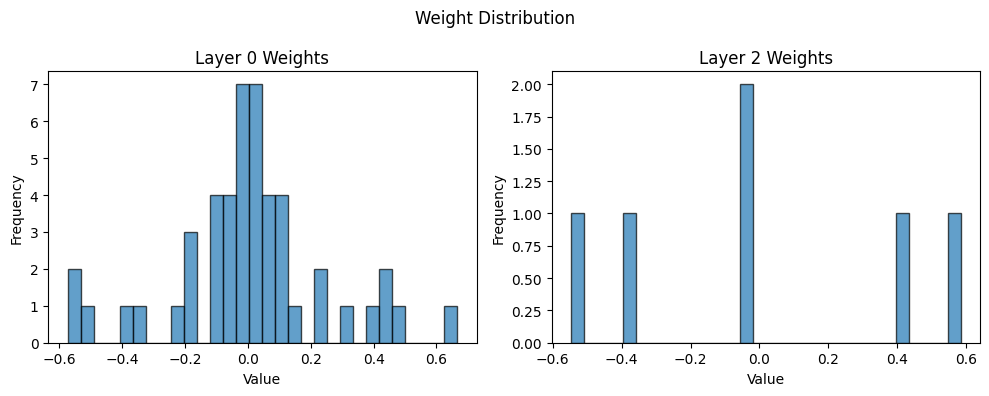

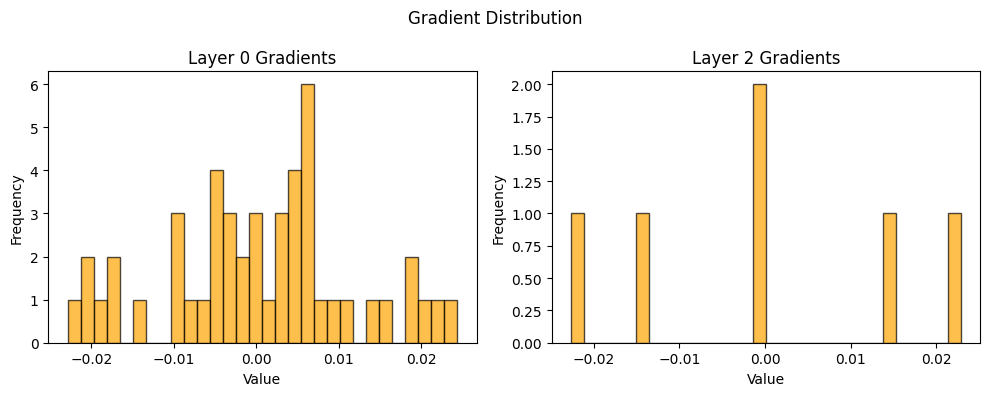

In [125]:
w1_layers = [0, 2]

w1_model.plot_weights(w1_layers)

w1_model.plot_gradients(w1_layers)

##### W2 Distribution + Gradient Weight Plot

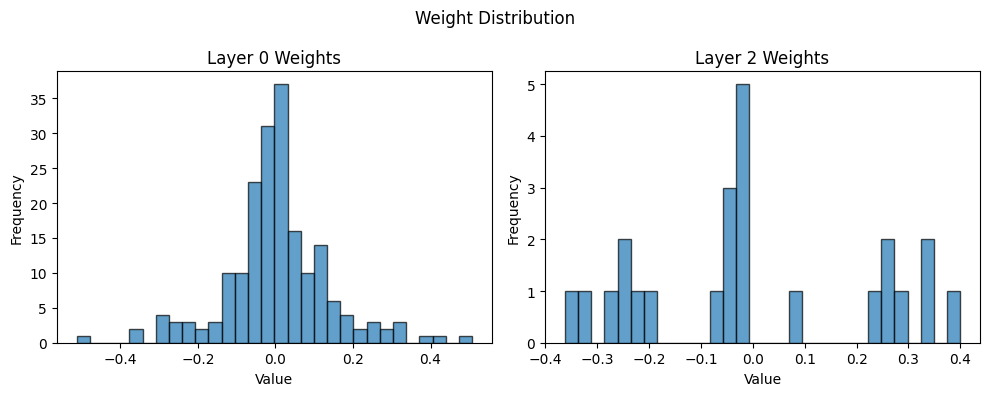

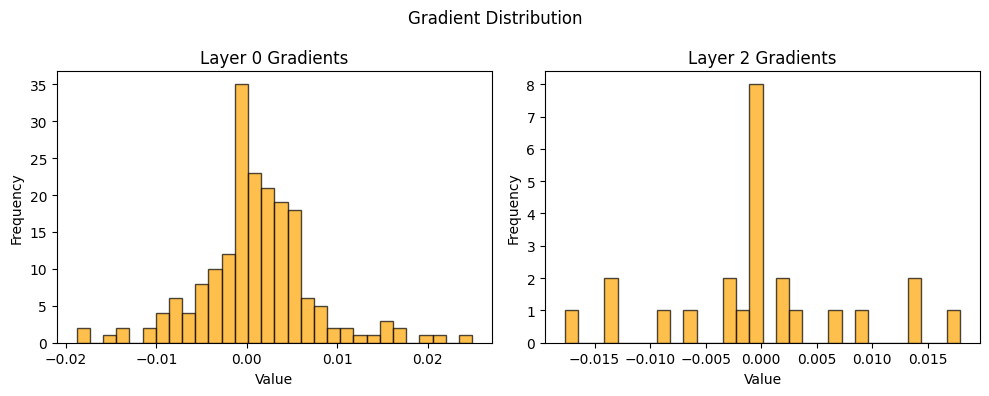

In [126]:
w2_layers = [0, 2]

w2_model.plot_weights(w2_layers)

w2_model.plot_gradients(w2_layers)

##### W3 Distribution + Gradient Weight Plot

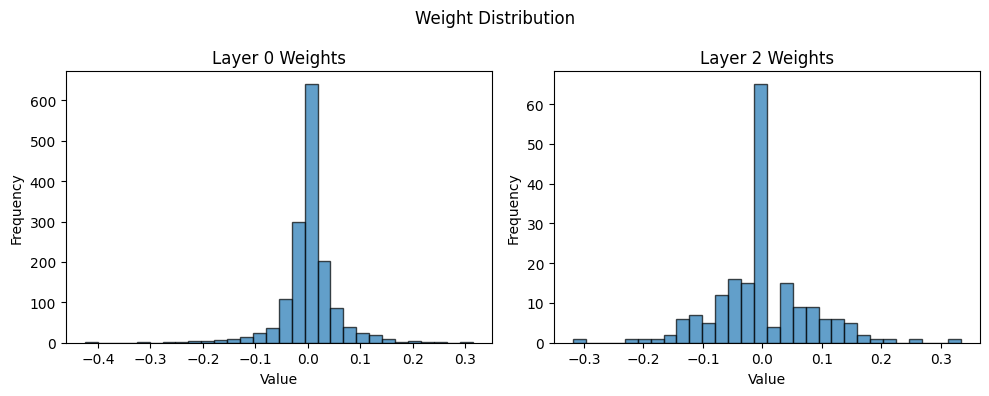

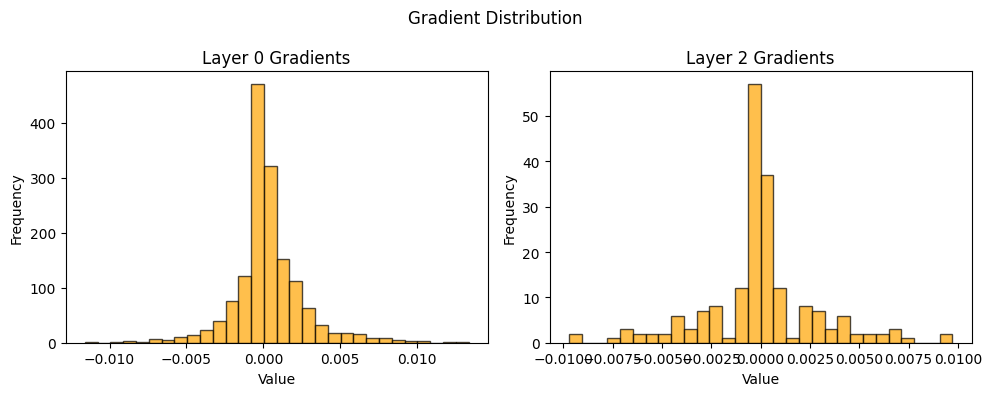

In [127]:
w3_layers = [0, 2]

w3_model.plot_weights(w3_layers)

w3_model.plot_gradients(w3_layers)

### Three variation of depth with the same width like the control

Depth variation (hidden layers): 
- 2
- 4
- 8


In [128]:
h1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

h2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

h3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

In [129]:
h1_history = h1_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h1_preds = h1_model.predict(X_test)
print(f"hidden layer depth = 2: {f1_score(y_test,h1_preds)}")

Epoch 1/20 [..............................] 2/250

Epoch 1/20 [==============================] - train_loss: 0.526689 - val_loss: 0.537049
Epoch 2/20 [==============================] - train_loss: 0.523063 - val_loss: 0.531757
Epoch 3/20 [==============================] - train_loss: 0.526744 - val_loss: 0.532514
Epoch 4/20 [==============================] - train_loss: 0.515681 - val_loss: 0.518023
Epoch 5/20 [==============================] - train_loss: 0.522447 - val_loss: 0.527859
Epoch 6/20 [==============================] - train_loss: 0.525387 - val_loss: 0.530206
Epoch 7/20 [==============================] - train_loss: 0.522810 - val_loss: 0.527888
Epoch 8/20 [==============================] - train_loss: 0.515400 - val_loss: 0.526393
Epoch 9/20 [==============================] - train_loss: 0.514753 - val_loss: 0.522131
Epoch 10/20 [==============================] - train_loss: 0.518722 - val_loss: 0.524321
Epoch 11/20 [==============================] - train_loss: 0.520640 - val_loss: 0.526394
Epoch 12/20 [=================

In [130]:
h2_history = h2_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h2_preds = h2_model.predict(X_test)
print(f"hidden layer depth = 4: {f1_score(y_test,h2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.537496 - val_loss: 0.546548
Epoch 2/20 [==============================] - train_loss: 0.536669 - val_loss: 0.543589
Epoch 3/20 [==============================] - train_loss: 0.561934 - val_loss: 0.564431
Epoch 4/20 [==============================] - train_loss: 0.530482 - val_loss: 0.531174
Epoch 5/20 [==============================] - train_loss: 0.531588 - val_loss: 0.534984
Epoch 6/20 [==============================] - train_loss: 0.535149 - val_loss: 0.538264
Epoch 7/20 [==============================] - train_loss: 0.537285 - val_loss: 0.541817
Epoch 8/20 [==============================] - train_loss: 0.533882 - val_loss: 0.542485
Epoch 9/20 [==============================] - train_loss: 0.527483 - val_loss: 0.533364
Epoch 10/20 [==============================] - train_loss: 0.537921 - val_loss: 0.539796
Epoch 11/20 [==============================] - train_loss: 0.562535 - val_loss: 0.564370
Epoch 12/20 [=================

In [131]:
h3_history = h3_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h3_preds = h3_model.predict(X_test)
print(f"hidden layer depth = 8: {f1_score(y_test,h3_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.714693 - val_loss: 0.714611
Epoch 2/20 [==============================] - train_loss: 0.693775 - val_loss: 0.693658
Epoch 3/20 [==============================] - train_loss: 0.687081 - val_loss: 0.686979
Epoch 4/20 [==============================] - train_loss: 0.682954 - val_loss: 0.682836
Epoch 5/20 [==============================] - train_loss: 0.682935 - val_loss: 0.682782
Epoch 6/20 [==============================] - train_loss: 0.685502 - val_loss: 0.685326
Epoch 7/20 [==============================] - train_loss: 0.679127 - val_loss: 0.678989
Epoch 8/20 [==============================] - train_loss: 0.678410 - val_loss: 0.678310
Epoch 9/20 [==============================] - train_loss: 0.677264 - val_loss: 0.677156
Epoch 10/20 [==============================] - train_loss: 0.678969 - val_loss: 0.678814
Epoch 11/20 [==============================] - train_loss: 0.676078 - val_loss: 0.675964
Epoch 12/20 [=================

#### Perbandingan

In [132]:
print(f"control: {f1_score(y_test,control_preds)}")
print(f"hidden layer depth = 2: {f1_score(y_test,h1_preds)}")
print(f"hidden layer depth = 4: {f1_score(y_test,h2_preds)}")
print(f"hidden layer depth = 8: {f1_score(y_test,h3_preds)}")

control: 0.7683664649956785
hidden layer depth = 2: 0.7649890590809628
hidden layer depth = 4: 0.755656108597285
hidden layer depth = 8: 0.7619931909625502


##### H1 Distribution + Gradient Weight Plot

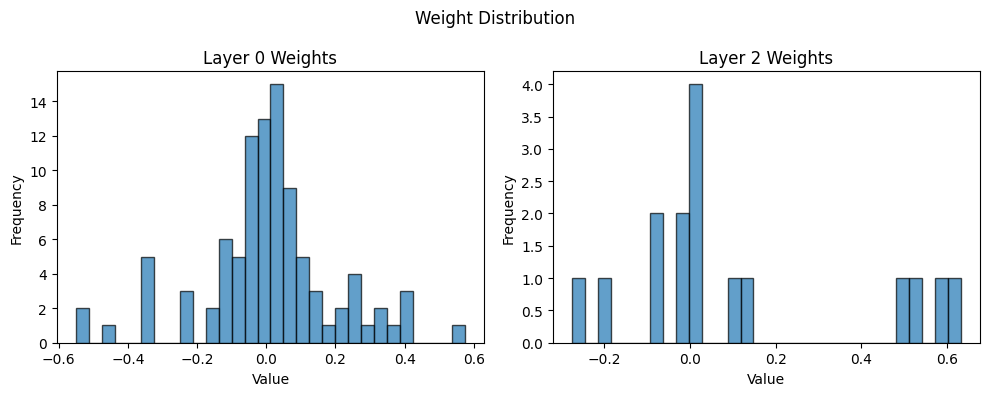

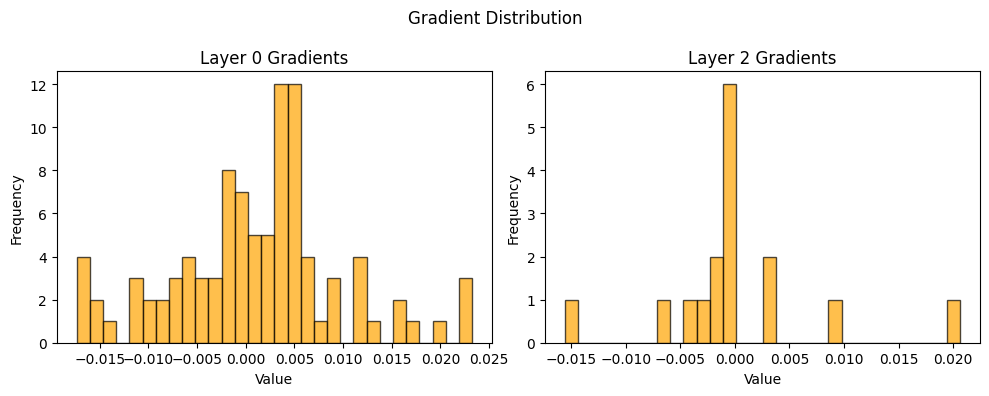

In [133]:
h1_layers = [0, 2]

h1_model.plot_weights(h1_layers)

h1_model.plot_gradients(h1_layers)

##### H2 Distribution + Gradient Weight Plot

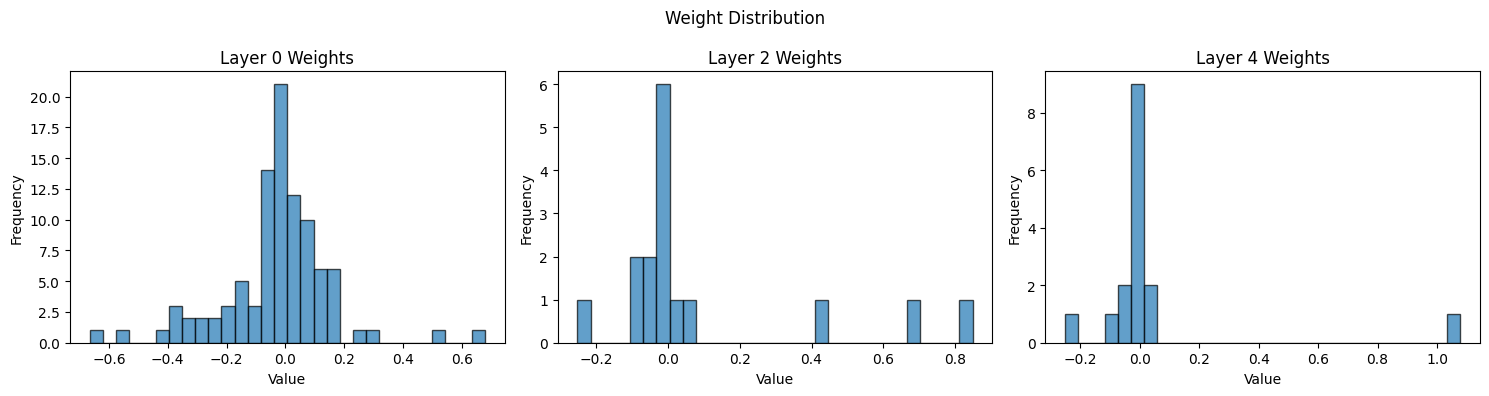

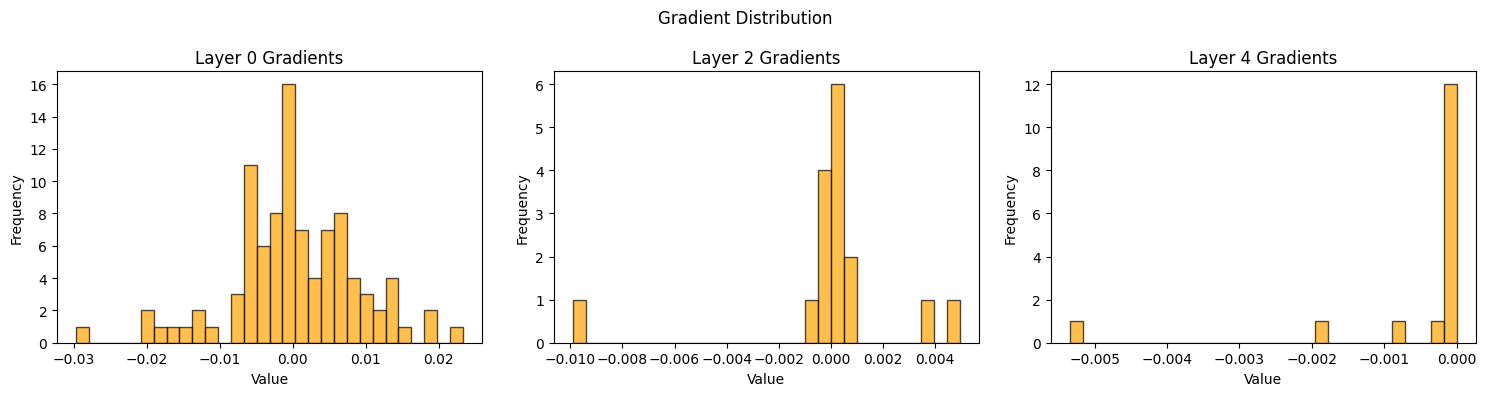

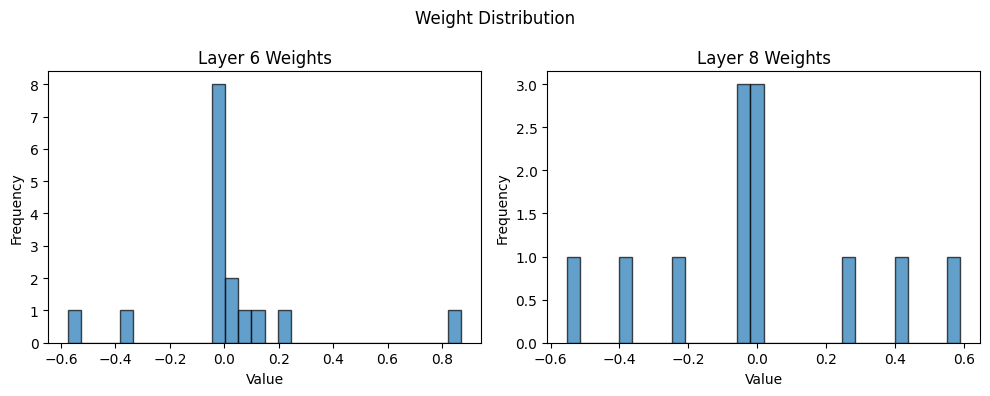

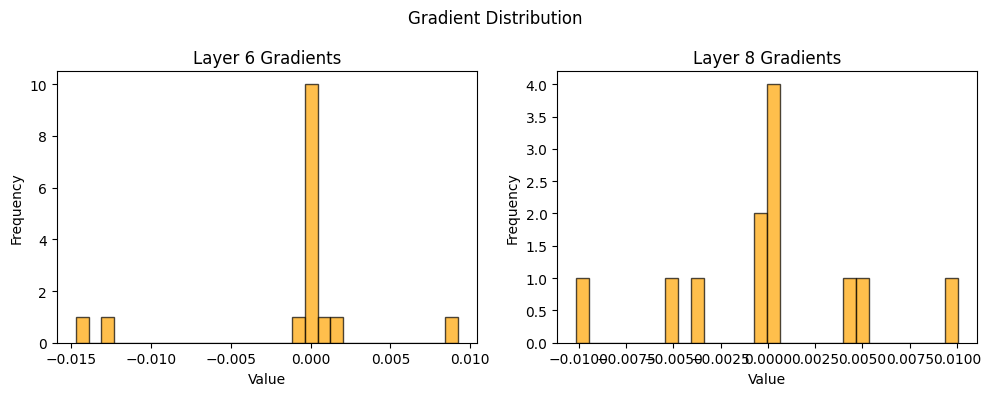

In [134]:
h2_layers = [0, 2, 4]

h2_model.plot_weights(h2_layers)

h2_model.plot_gradients(h2_layers)

h2_layers = [6, 8]

h2_model.plot_weights(h2_layers)

h2_model.plot_gradients(h2_layers)

##### H3 Distribution + Gradient Weight Plot

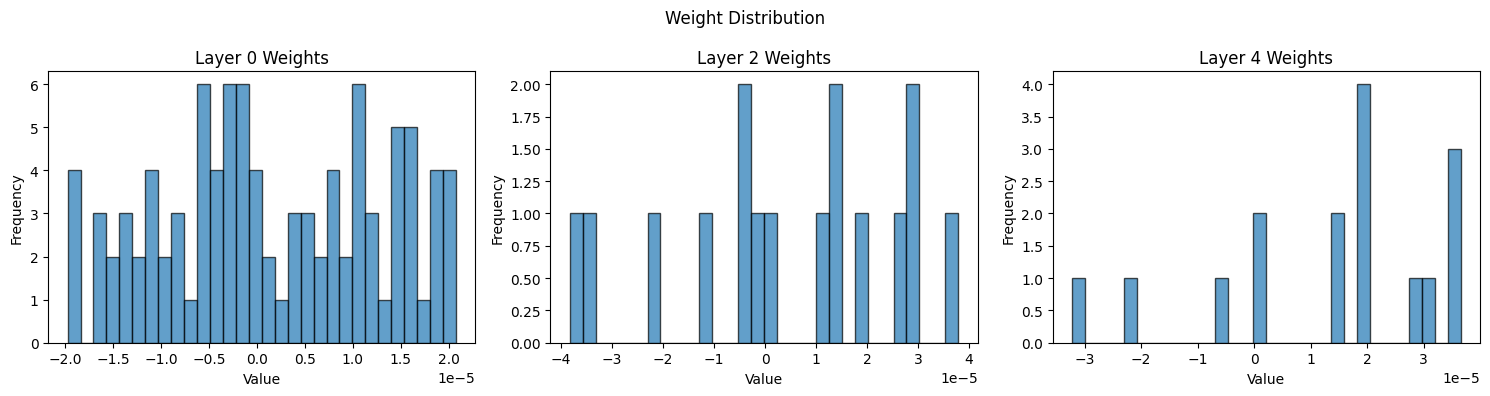

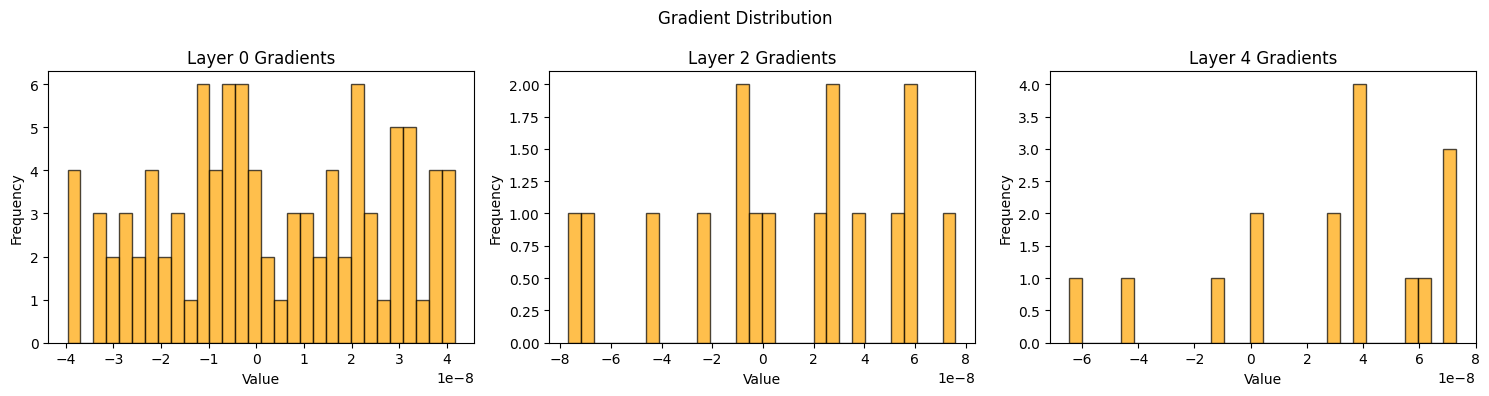

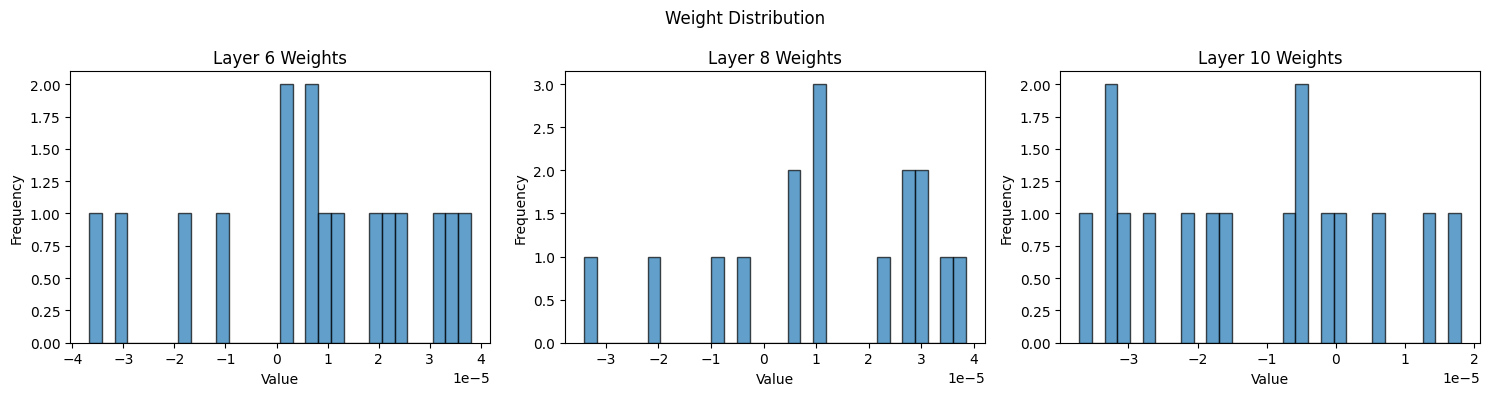

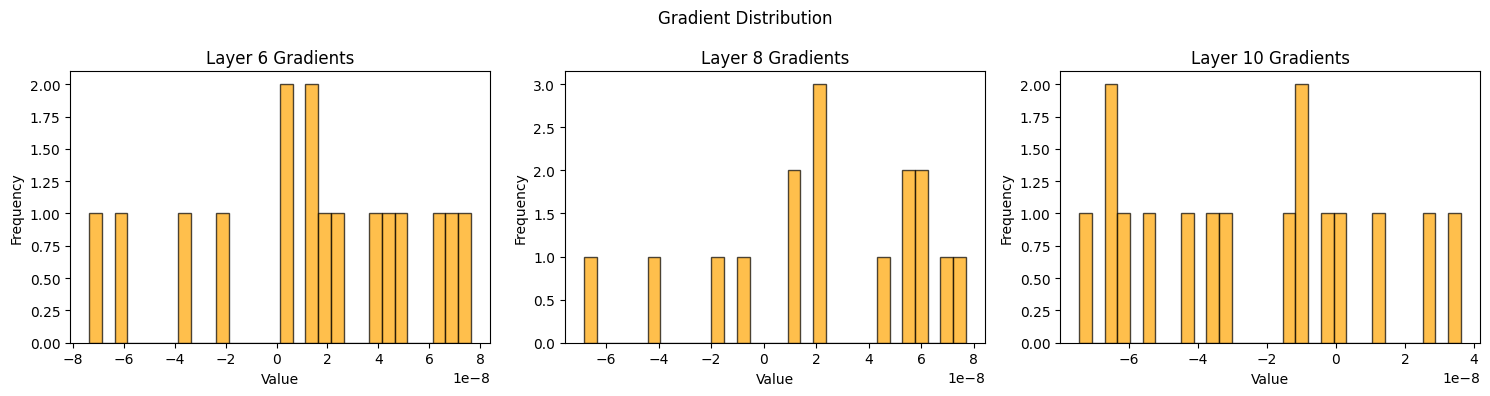

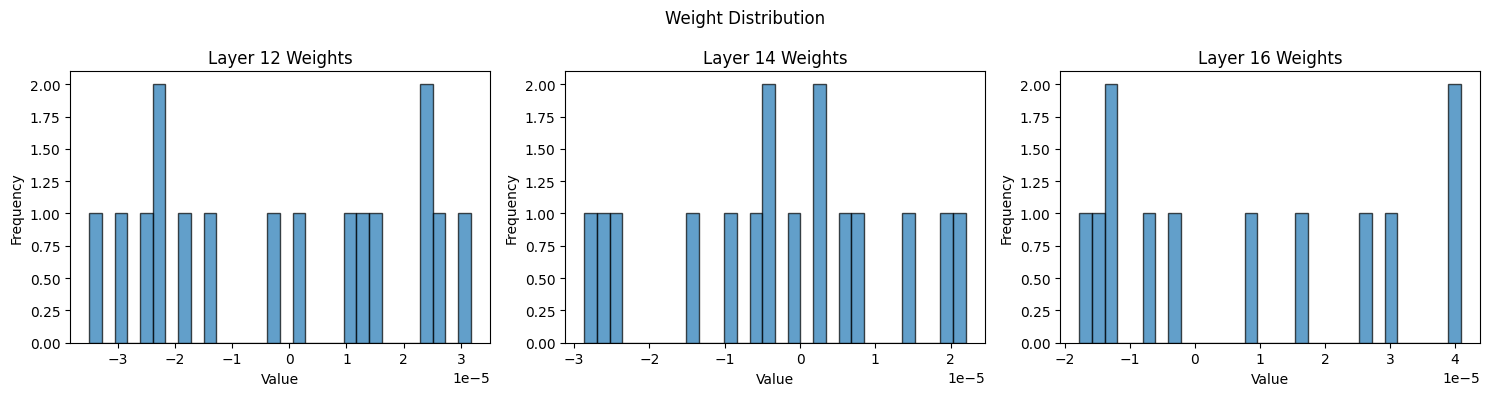

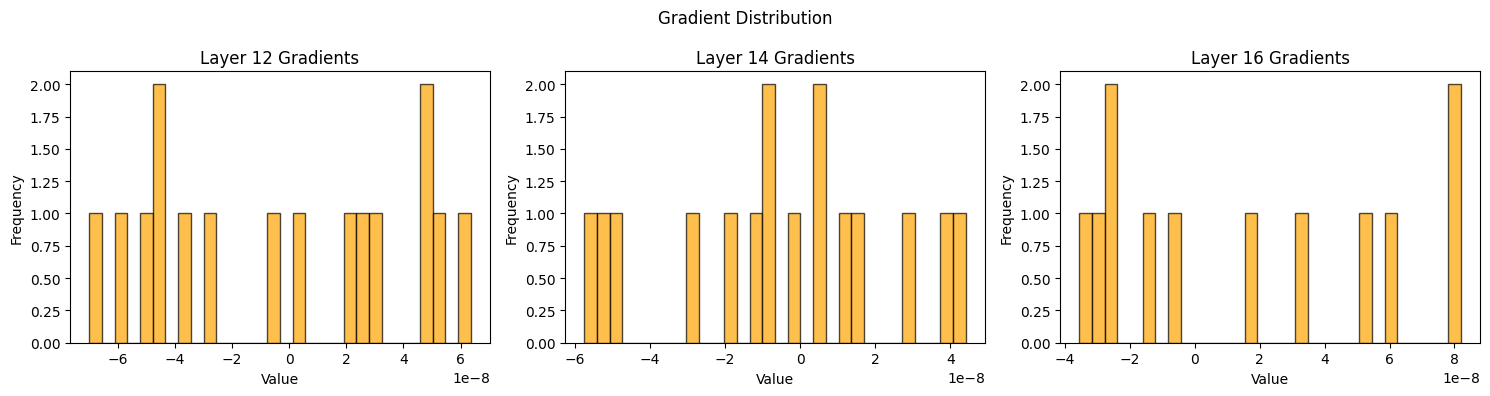

In [135]:
h3_layers = [0, 2, 4]

h3_model.plot_weights(h3_layers)

h3_model.plot_gradients(h3_layers)

h3_layers = [6, 8, 10]

h3_model.plot_weights(h3_layers)

h3_model.plot_gradients(h3_layers)

h3_layers = [12, 14, 16]

h3_model.plot_weights(h3_layers)

h3_model.plot_gradients(h3_layers)

### All variation of Activation Layer

FFNN is structured to have one of each input, hidden and output layer

Hidden layer variations are:

- RELU
- Leaky RELU
- ELU
- Sigmoid
- Tanh
- RMS Norm

In [136]:
relu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

leaky_relu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.LeakyRelu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

elu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.ELU(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

sigmoid_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Sigmoid(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

tanh_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Tanh(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

rmsnorm_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.RMSNorm(4), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)




In [137]:
relu_history = relu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
relu_preds = relu_model.predict(X_test)
print(f"hidden layer activation = RELU: {f1_score(y_test,relu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.524921 - val_loss: 0.533840
Epoch 2/20 [==============================] - train_loss: 0.520618 - val_loss: 0.527968
Epoch 3/20 [==============================] - train_loss: 0.520049 - val_loss: 0.526489
Epoch 4/20 [==============================] - train_loss: 0.514063 - val_loss: 0.515256
Epoch 5/20 [==============================] - train_loss: 0.515952 - val_loss: 0.520767
Epoch 6/20 [==============================] - train_loss: 0.526980 - val_loss: 0.532186
Epoch 7/20 [==============================] - train_loss: 0.518627 - val_loss: 0.526115
Epoch 8/20 [==============================] - train_loss: 0.510813 - val_loss: 0.521963
Epoch 9/20 [==============================] - train_loss: 0.512431 - val_loss: 0.521039
Epoch 10/20 [==============================] - train_loss: 0.514581 - val_loss: 0.520623
Epoch 11/20 [==============================] - train_loss: 0.509169 - val_loss: 0.511934
Epoch 12/20 [=================

In [138]:
leaky_relu_history = leaky_relu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
leaky_relu_preds = leaky_relu_model.predict(X_test)
print(f"hidden layer activation = Leaky RELU: {f1_score(y_test, leaky_relu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.524539 - val_loss: 0.531593
Epoch 2/20 [==============================] - train_loss: 0.520766 - val_loss: 0.526489
Epoch 3/20 [==============================] - train_loss: 0.523762 - val_loss: 0.529166
Epoch 4/20 [==============================] - train_loss: 0.515590 - val_loss: 0.515852
Epoch 5/20 [==============================] - train_loss: 0.517206 - val_loss: 0.522141
Epoch 6/20 [==============================] - train_loss: 0.529497 - val_loss: 0.533235
Epoch 7/20 [==============================] - train_loss: 0.520768 - val_loss: 0.525726
Epoch 8/20 [==============================] - train_loss: 0.512110 - val_loss: 0.520751
Epoch 9/20 [==============================] - train_loss: 0.514292 - val_loss: 0.520491
Epoch 10/20 [==============================] - train_loss: 0.515424 - val_loss: 0.519936
Epoch 11/20 [==============================] - train_loss: 0.514066 - val_loss: 0.516387
Epoch 12/20 [=================

In [139]:
elu_history = elu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
elu_preds = elu_model.predict(X_test)
print(f"hidden layer activation = ELU: {f1_score(y_test, elu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.526787 - val_loss: 0.533601
Epoch 2/20 [==============================] - train_loss: 0.520866 - val_loss: 0.526101
Epoch 3/20 [==============================] - train_loss: 0.521032 - val_loss: 0.526383
Epoch 4/20 [==============================] - train_loss: 0.514572 - val_loss: 0.514039
Epoch 5/20 [==============================] - train_loss: 0.514878 - val_loss: 0.518060
Epoch 6/20 [==============================] - train_loss: 0.525884 - val_loss: 0.528214
Epoch 7/20 [==============================] - train_loss: 0.517283 - val_loss: 0.520827
Epoch 8/20 [==============================] - train_loss: 0.509434 - val_loss: 0.516559
Epoch 9/20 [==============================] - train_loss: 0.511966 - val_loss: 0.516987
Epoch 10/20 [==============================] - train_loss: 0.511588 - val_loss: 0.514256
Epoch 11/20 [==============================] - train_loss: 0.507050 - val_loss: 0.509335
Epoch 12/20 [=================

In [140]:
rmsnorm_history = rmsnorm_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
rmsnorm_preds = rmsnorm_model.predict(X_test)
print(f"hidden layer activation = RMS Norm: {f1_score(y_test, rmsnorm_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.536752 - val_loss: 0.545240
Epoch 2/20 [==============================] - train_loss: 0.527776 - val_loss: 0.535373
Epoch 3/20 [==============================] - train_loss: 0.526424 - val_loss: 0.532869
Epoch 4/20 [==============================] - train_loss: 0.519865 - val_loss: 0.519403
Epoch 5/20 [==============================] - train_loss: 0.518670 - val_loss: 0.522858
Epoch 6/20 [==============================] - train_loss: 0.528036 - val_loss: 0.530840
Epoch 7/20 [==============================] - train_loss: 0.519964 - val_loss: 0.524094
Epoch 8/20 [==============================] - train_loss: 0.511352 - val_loss: 0.519280
Epoch 9/20 [==============================] - train_loss: 0.514393 - val_loss: 0.520351
Epoch 10/20 [==============================] - train_loss: 0.512559 - val_loss: 0.515400
Epoch 11/20 [==============================] - train_loss: 0.508612 - val_loss: 0.510974
Epoch 12/20 [=================

In [141]:
tanh_history =tanh_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
tanh_preds = tanh_model.predict(X_test)
print(f"hidden layer activation = Tanh: {f1_score(y_test, tanh_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.531427 - val_loss: 0.539459
Epoch 2/20 [==============================] - train_loss: 0.525708 - val_loss: 0.532609
Epoch 3/20 [==============================] - train_loss: 0.524803 - val_loss: 0.531267
Epoch 4/20 [==============================] - train_loss: 0.519326 - val_loss: 0.519045
Epoch 5/20 [==============================] - train_loss: 0.519550 - val_loss: 0.523581
Epoch 6/20 [==============================] - train_loss: 0.527597 - val_loss: 0.530156
Epoch 7/20 [==============================] - train_loss: 0.520558 - val_loss: 0.524580
Epoch 8/20 [==============================] - train_loss: 0.512430 - val_loss: 0.519970
Epoch 9/20 [==============================] - train_loss: 0.514903 - val_loss: 0.520075
Epoch 10/20 [==============================] - train_loss: 0.515191 - val_loss: 0.517858
Epoch 11/20 [==============================] - train_loss: 0.510538 - val_loss: 0.512848
Epoch 12/20 [=================

In [142]:
sigmoid_history = sigmoid_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
sigmoid_preds = sigmoid_model.predict(X_test)
print(f"hidden layer activation = Sigmoid: {f1_score(y_test, sigmoid_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.526503 - val_loss: 0.529850
Epoch 2/20 [==============================] - train_loss: 0.522156 - val_loss: 0.525827
Epoch 3/20 [==============================] - train_loss: 0.520293 - val_loss: 0.524410
Epoch 4/20 [==============================] - train_loss: 0.516024 - val_loss: 0.516843
Epoch 5/20 [==============================] - train_loss: 0.518088 - val_loss: 0.520471
Epoch 6/20 [==============================] - train_loss: 0.524341 - val_loss: 0.525886
Epoch 7/20 [==============================] - train_loss: 0.517977 - val_loss: 0.520720
Epoch 8/20 [==============================] - train_loss: 0.512018 - val_loss: 0.516206
Epoch 9/20 [==============================] - train_loss: 0.513699 - val_loss: 0.516653
Epoch 10/20 [==============================] - train_loss: 0.514671 - val_loss: 0.516364
Epoch 11/20 [==============================] - train_loss: 0.513458 - val_loss: 0.515820
Epoch 12/20 [=================

#### Perbandingan

In [143]:

print(f"control: {f1_score(y_test,control_preds)}")
print(f"hidden layer activation = RELU: {f1_score(y_test,relu_preds)}")
print(f"hidden layer activation = Leaky RELU: {f1_score(y_test, leaky_relu_preds)}")
print(f"hidden layer activation = ELU: {f1_score(y_test, elu_preds)}")
print(f"hidden layer activation = RMS Norm: {f1_score(y_test, rmsnorm_preds)}")
print(f"hidden layer activation = Tanh: {f1_score(y_test, tanh_preds)}")
print(f"hidden layer activation = Sigmoid: {f1_score(y_test, sigmoid_preds)}")


control: 0.7683664649956785
hidden layer activation = RELU: 0.7636047017849369
hidden layer activation = Leaky RELU: 0.7723367697594502
hidden layer activation = ELU: 0.7736976942783945
hidden layer activation = RMS Norm: 0.7726495726495727
hidden layer activation = Tanh: 0.7705553164012053
hidden layer activation = Sigmoid: 0.7696267696267697


In [144]:
hidden_layers = [0, 2]

##### RELU Distribution + Gradient Weight Plot

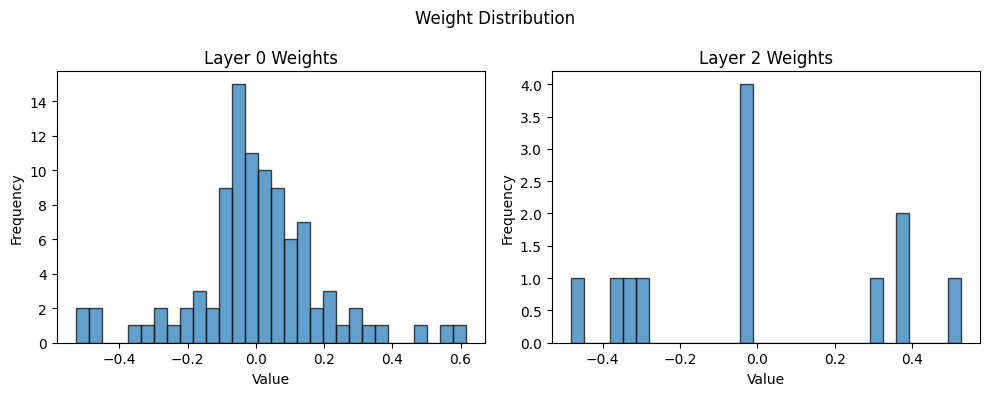

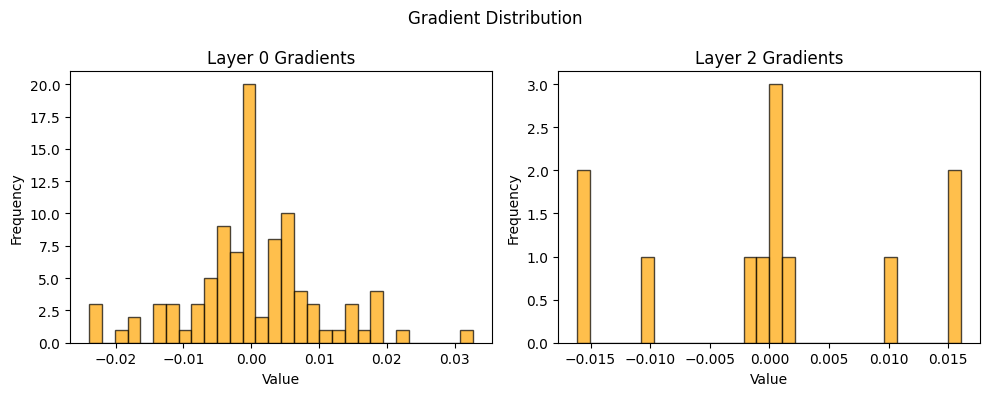

In [145]:
relu_model.plot_weights(hidden_layers)

relu_model.plot_gradients(hidden_layers)

##### Leaky RELU Distribution + Gradient Weight Plot

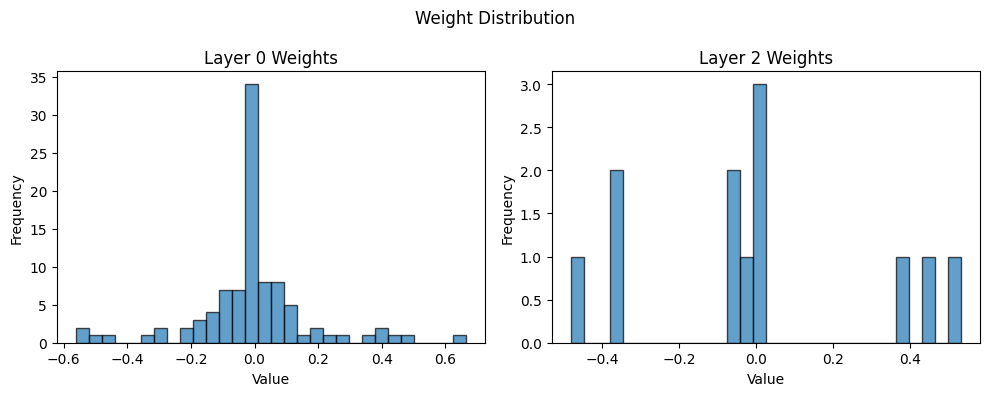

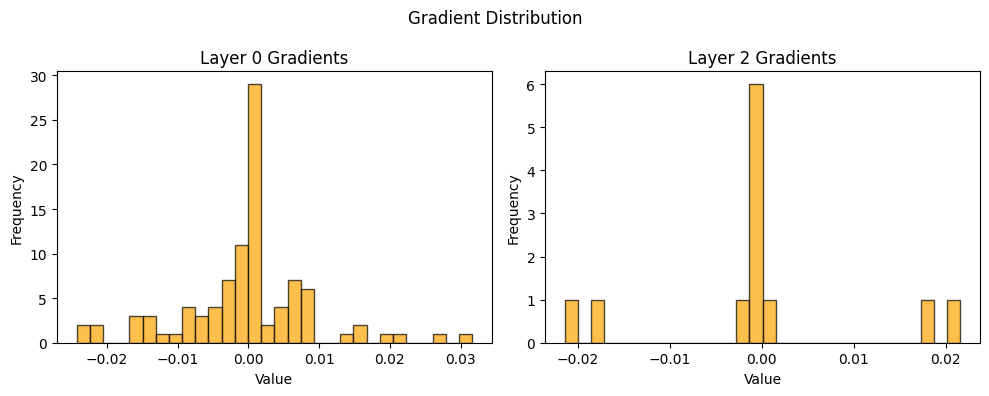

In [146]:
leaky_relu_model.plot_weights(hidden_layers)

leaky_relu_model.plot_gradients(hidden_layers)

##### ELU Distribution + Gradient Weight Plot

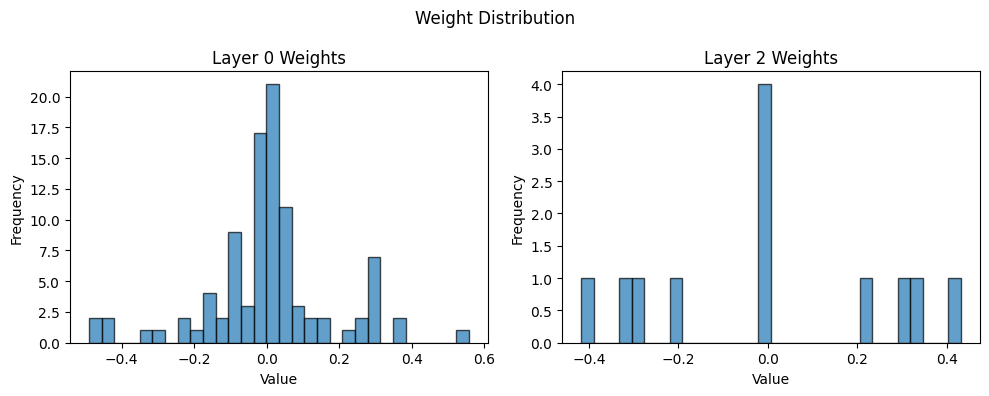

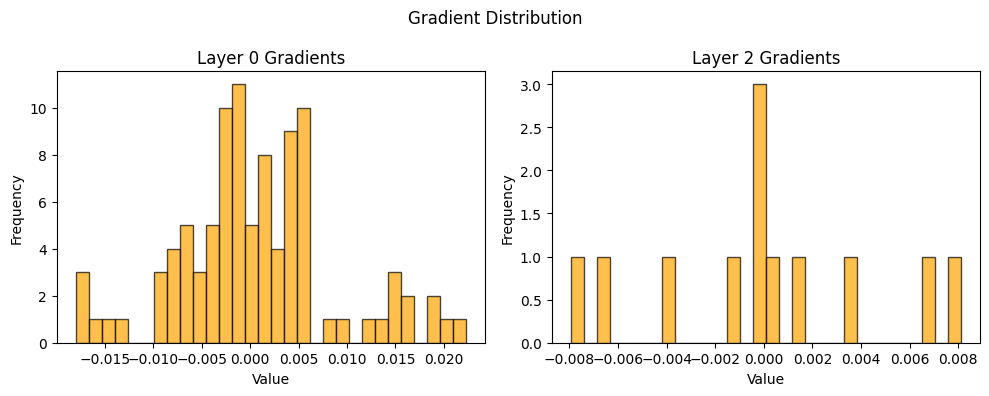

In [147]:
elu_model.plot_weights(hidden_layers)

elu_model.plot_gradients(hidden_layers)

##### RMS Norm Distribution + Gradient Weight Plot

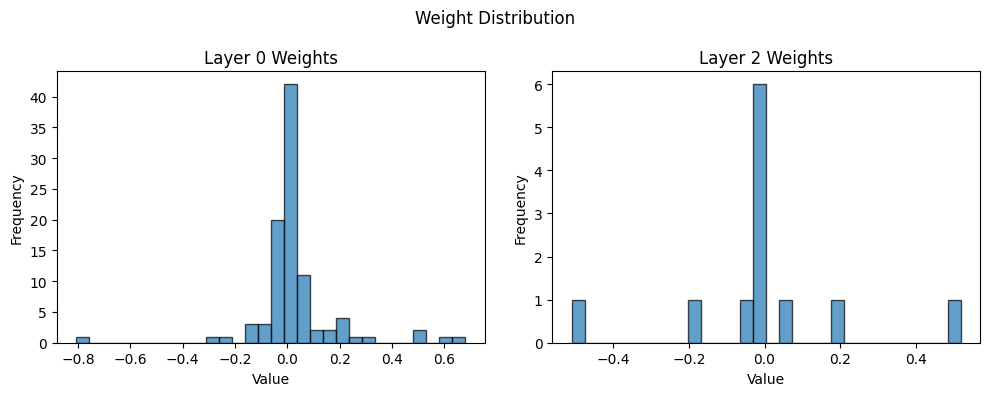

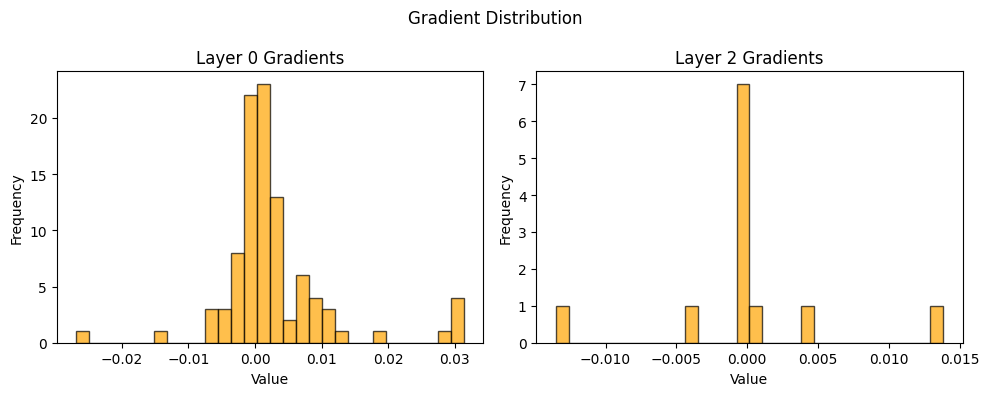

In [148]:
rmsnorm_model.plot_weights(hidden_layers)

rmsnorm_model.plot_gradients(hidden_layers)

##### Tanh Distribution + Gradient Weight Plot

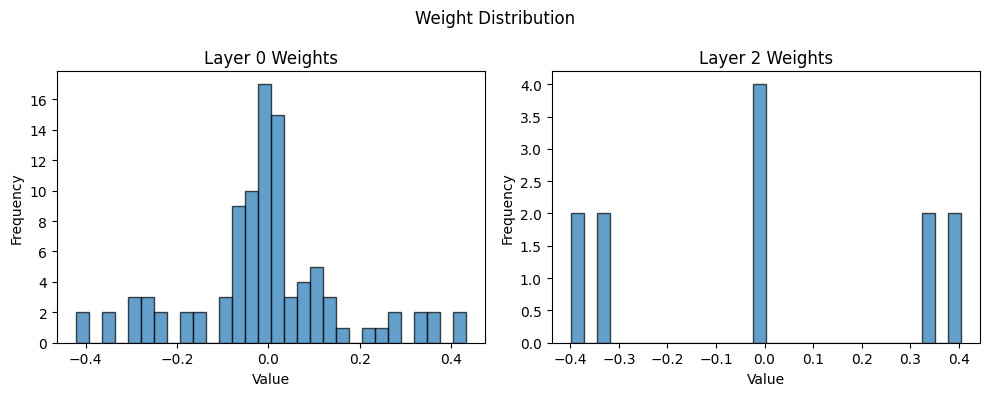

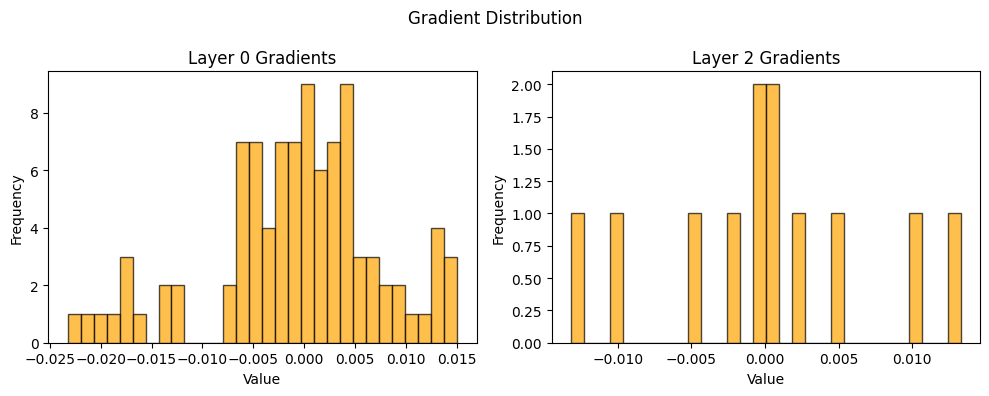

In [149]:
tanh_model.plot_weights(hidden_layers)

tanh_model.plot_gradients(hidden_layers)

##### Sigmoid Distribution + Gradient Weight Plot

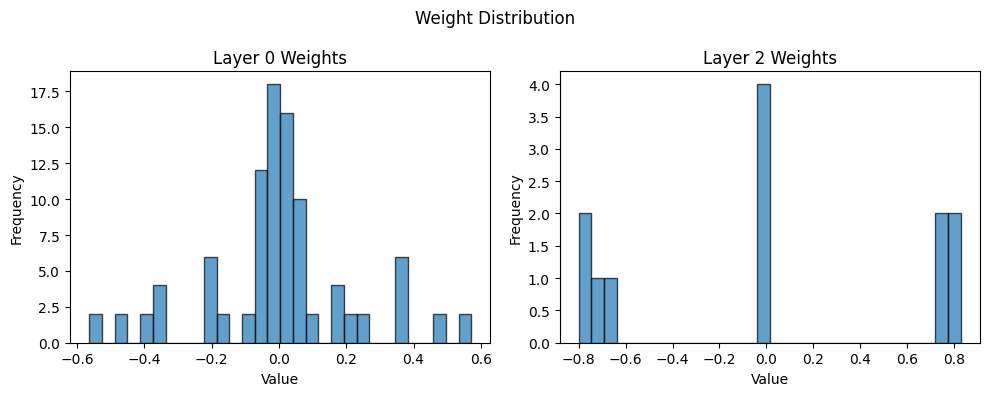

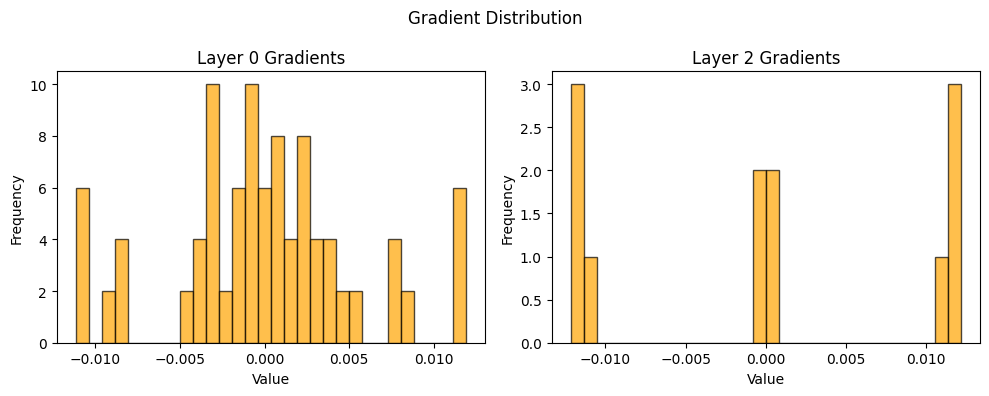

In [150]:
sigmoid_model.plot_weights(hidden_layers)

sigmoid_model.plot_gradients(hidden_layers)

### Three variation of Learning Rate

Using the same control model, we will modify the learning rate when fitting train data

Variation of learning rates:

- 0.1
- 10
- 40

In [151]:
lr1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

lr2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

lr3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [152]:
lr1_history = lr1_model.fit(X_train, y_train, epochs=20, lr=0.1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr1_preds = lr1_model.predict(X_test)
print(f"Learning Rate = 0.1: {f1_score(y_test,lr1_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.630928 - val_loss: 0.637587
Epoch 2/20 [==============================] - train_loss: 0.561502 - val_loss: 0.569583
Epoch 3/20 [==============================] - train_loss: 0.541048 - val_loss: 0.548335
Epoch 4/20 [==============================] - train_loss: 0.529918 - val_loss: 0.535372
Epoch 5/20 [==============================] - train_loss: 0.524081 - val_loss: 0.529216
Epoch 6/20 [==============================] - train_loss: 0.520114 - val_loss: 0.523981
Epoch 7/20 [==============================] - train_loss: 0.517783 - val_loss: 0.521706
Epoch 8/20 [==============================] - train_loss: 0.514581 - val_loss: 0.518727
Epoch 9/20 [==============================] - train_loss: 0.513843 - val_loss: 0.517112
Epoch 10/20 [==============================] - train_loss: 0.512191 - val_loss: 0.514812
Epoch 11/20 [==============================] - train_loss: 0.510743 - val_loss: 0.513400
Epoch 12/20 [=================

In [153]:
lr2_history = lr2_model.fit(X_train, y_train, epochs=20, lr=10, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr2_preds = lr2_model.predict(X_test)
print(f"Learning Rate = 10: {f1_score(y_test,lr2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.680093 - val_loss: 0.672954
Epoch 2/20 [==============================] - train_loss: 0.857857 - val_loss: 0.881046
Epoch 3/20 [==============================] - train_loss: 0.780316 - val_loss: 0.795331
Epoch 4/20 [==============================] - train_loss: 0.666167 - val_loss: 0.649482
Epoch 5/20 [==============================] - train_loss: 0.741929 - val_loss: 0.734019
Epoch 6/20 [==============================] - train_loss: 0.624014 - val_loss: 0.629192
Epoch 7/20 [==============================] - train_loss: 0.774532 - val_loss: 0.816043
Epoch 8/20 [==============================] - train_loss: 0.654746 - val_loss: 0.657989
Epoch 9/20 [==============================] - train_loss: 0.832731 - val_loss: 0.815297
Epoch 10/20 [==============================] - train_loss: 0.838181 - val_loss: 0.836185
Epoch 11/20 [==============================] - train_loss: 1.111723 - val_loss: 1.123088
Epoch 12/20 [=================

In [154]:
lr3_history = lr3_model.fit(X_train, y_train, epochs=20, lr=40, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr3_preds = lr3_model.predict(X_test)
print(f"Learning Rate = 40: {f1_score(y_test,lr3_preds)}")

Epoch 1/20 [==============================] - train_loss: 2.542919 - val_loss: 2.541268
Epoch 2/20 [==============================] - train_loss: 4.116529 - val_loss: 4.113854
Epoch 3/20 [==============================] - train_loss: 3.949081 - val_loss: 3.946515
Epoch 4/20 [==============================] - train_loss: 3.648090 - val_loss: 3.645720
Epoch 5/20 [==============================] - train_loss: 2.702354 - val_loss: 2.700598
Epoch 6/20 [==============================] - train_loss: 6.132397 - val_loss: 6.128412
Epoch 7/20 [==============================] - train_loss: 6.131497 - val_loss: 6.127513
Epoch 8/20 [==============================] - train_loss: 6.130595 - val_loss: 6.126612
Epoch 9/20 [==============================] - train_loss: 6.129691 - val_loss: 6.125708
Epoch 10/20 [==============================] - train_loss: 6.128785 - val_loss: 6.124803
Epoch 11/20 [==============================] - train_loss: 6.127877 - val_loss: 6.123895
Epoch 12/20 [=================

#### Perbandingan

In [155]:
print(f"control: {f1_score(y_test,control_preds)}")
print(f"Learning Rate = 0.1: {f1_score(y_test,lr1_preds)}")
print(f"Learning Rate = 10: {f1_score(y_test,lr2_preds)}")
print(f"Learning Rate = 40: {f1_score(y_test,lr3_preds)}")

control: 0.7683664649956785
Learning Rate = 0.1: 0.7952787952787953
Learning Rate = 10: 0.6690140845070423
Learning Rate = 40: 0.7619931909625502


In [156]:
lr_layers = [0, 2]

##### lr1 Distribution + Gradient Weight Plot

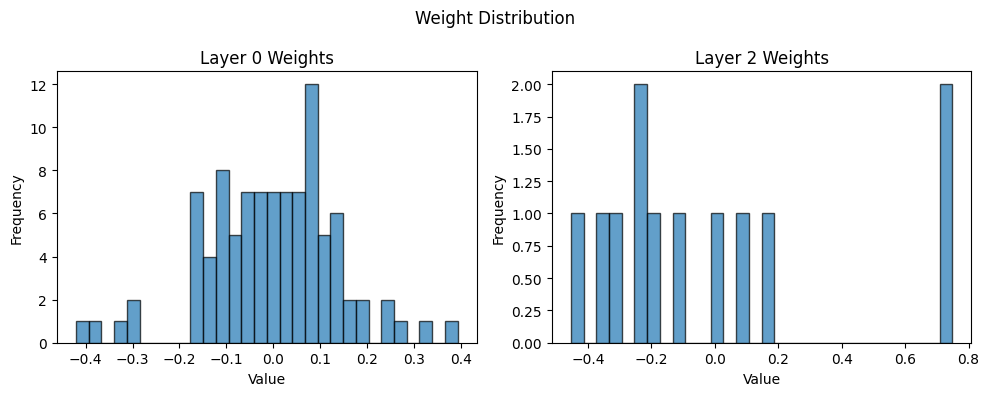

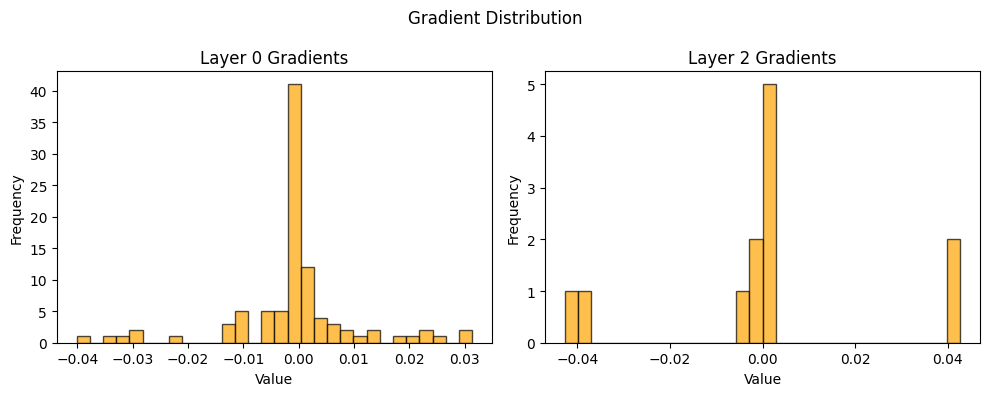

In [157]:
lr1_model.plot_weights(lr_layers)

lr1_model.plot_gradients(lr_layers)

##### lr2 Distribution + Gradient Weight Plot

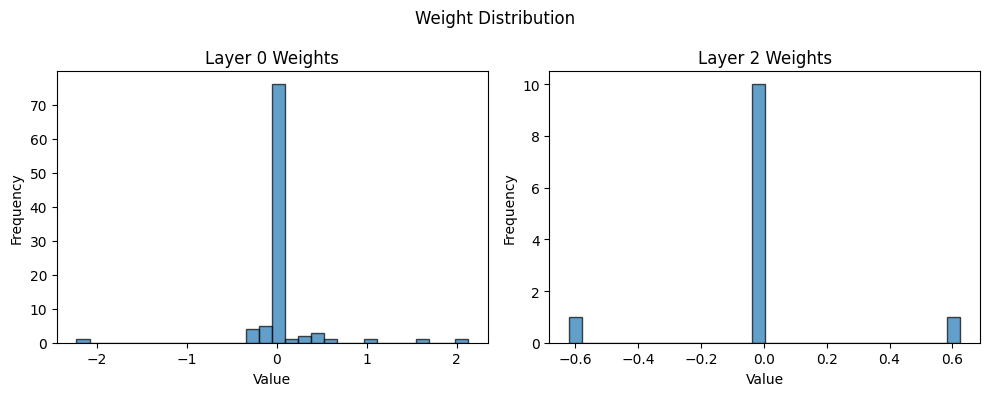

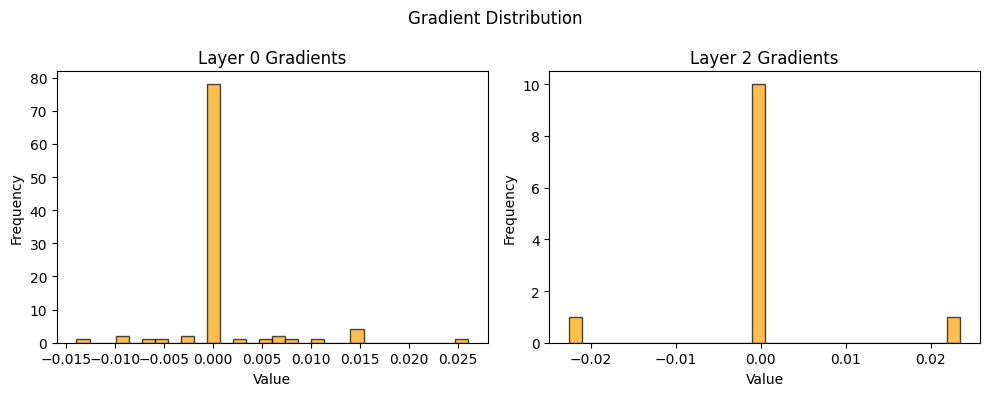

In [158]:
lr2_model.plot_weights(lr_layers)

lr2_model.plot_gradients(lr_layers)

##### lr3 Distribution + Gradient Weight Plot

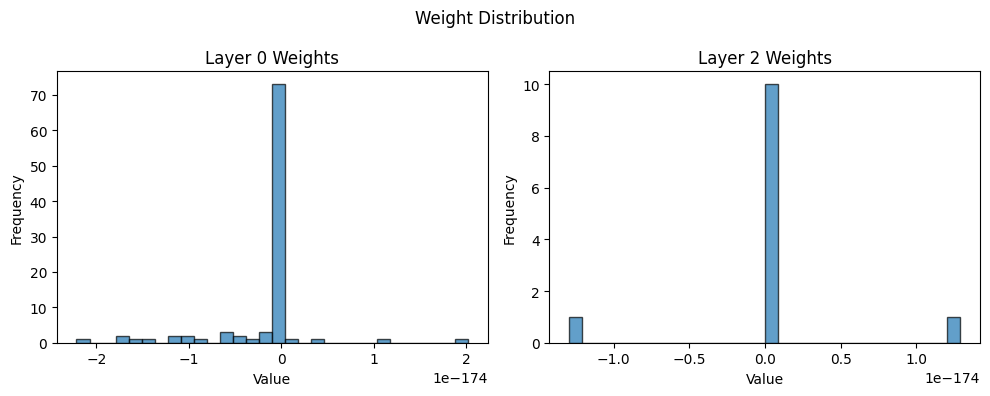

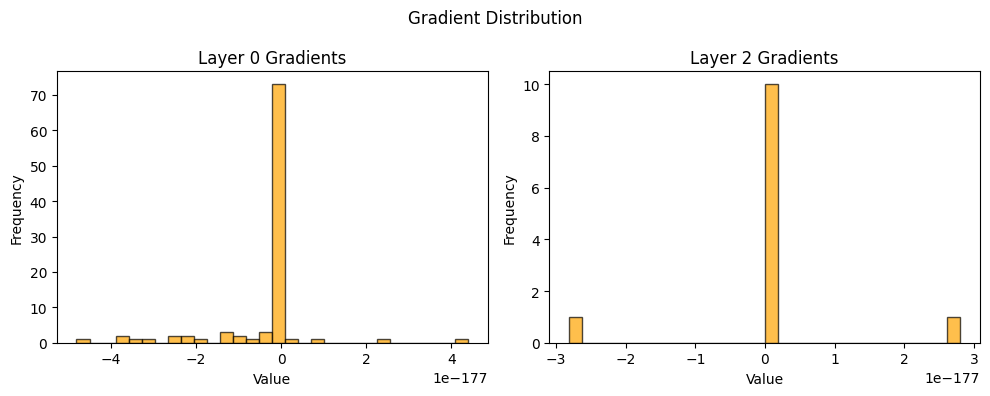

In [159]:
lr3_model.plot_weights(lr_layers)

lr3_model.plot_gradients(lr_layers)

### Training & Validation Loss Graphs

Display Training Loss & Validation Loss on each graph

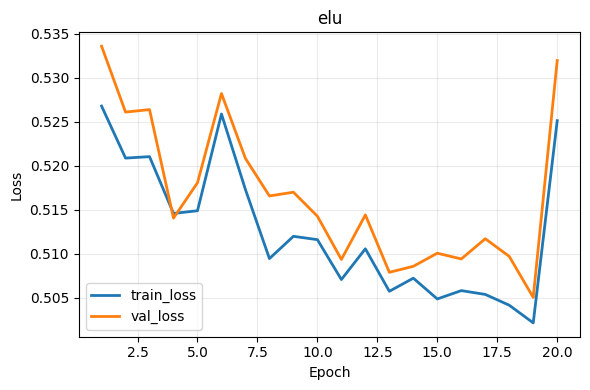

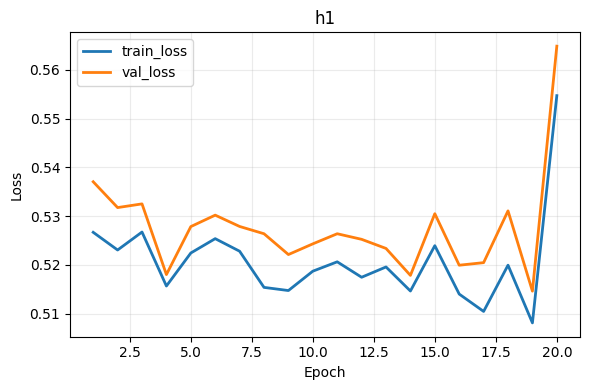

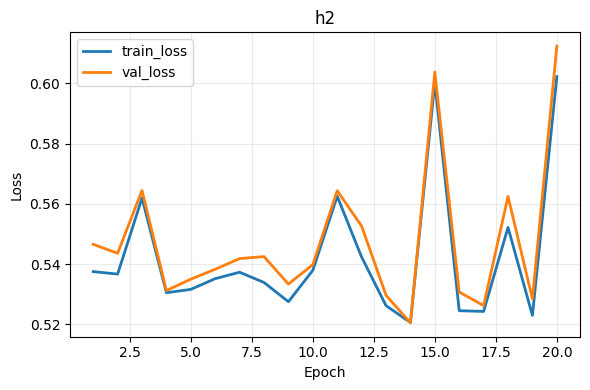

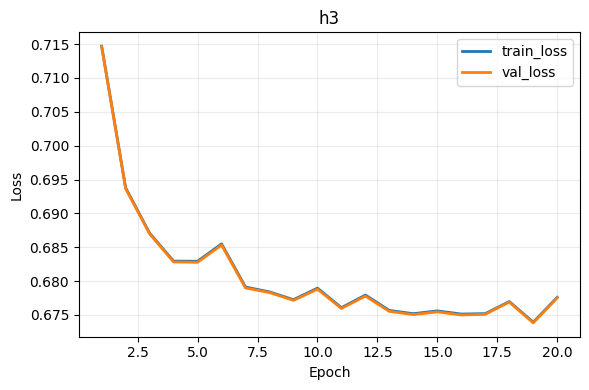

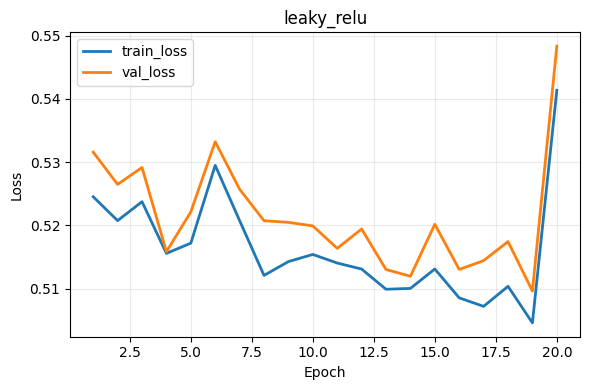

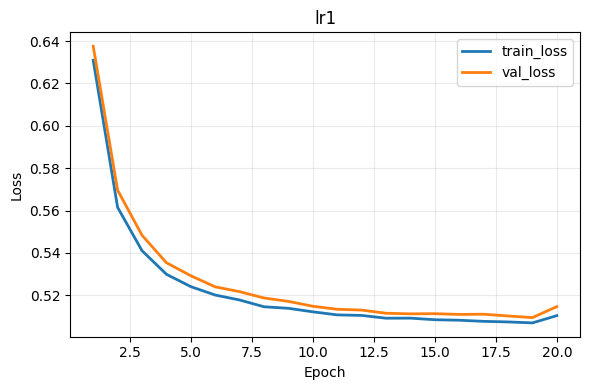

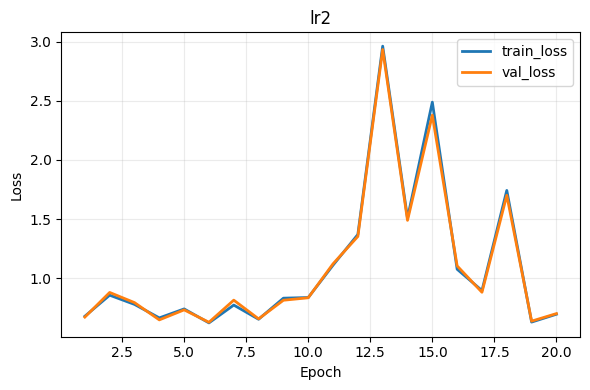

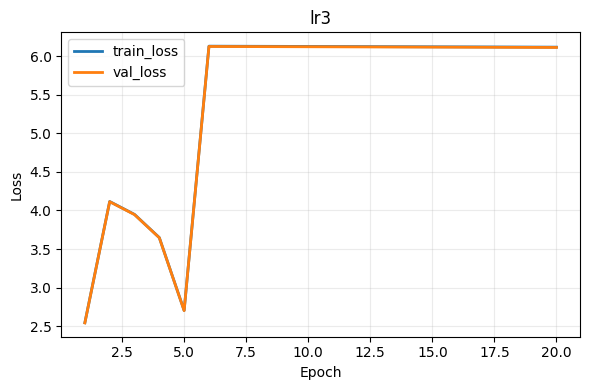

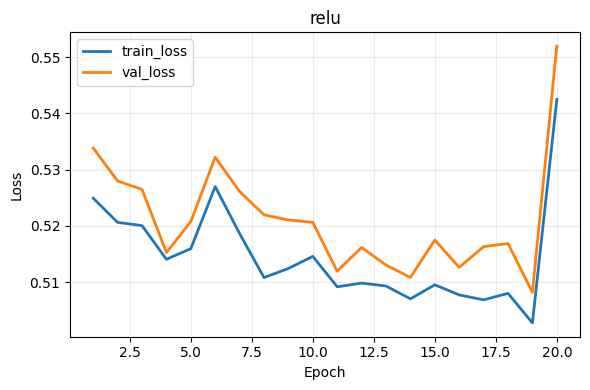

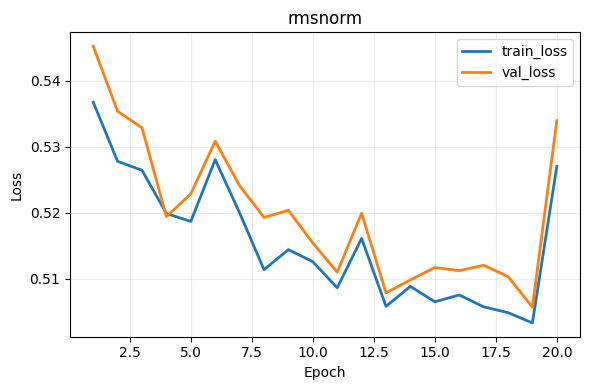

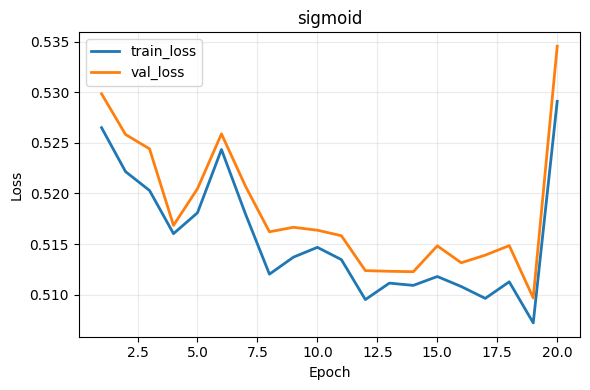

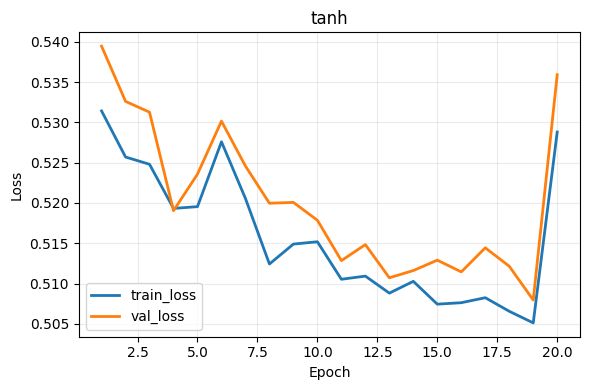

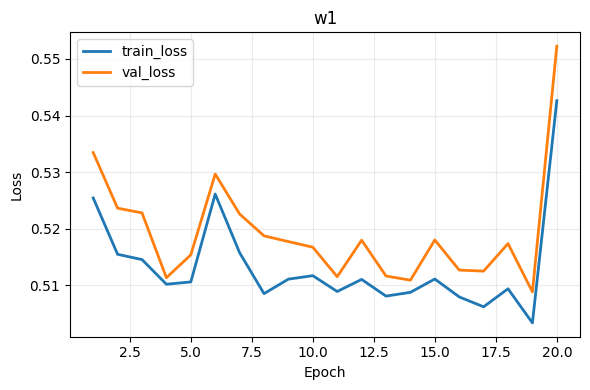

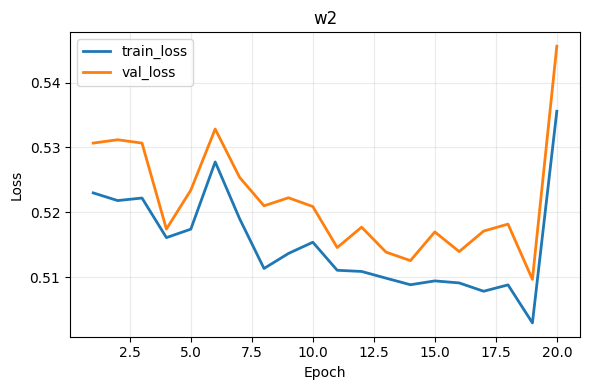

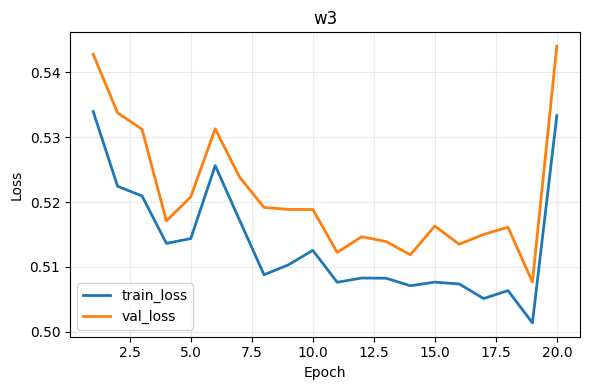

In [160]:
history_items = sorted(
    (name, value)
    for name, value in globals().items()
    if name.endswith("_history") and isinstance(value, dict)
)

if not history_items:
    raise ValueError("No *_history variables found. Run the training cells first.")

for name, history in history_items:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    train_loss = history.get("train_loss", [])
    val_loss = history.get("val_loss", [])

    if train_loss:
        train_epochs = range(1, len(train_loss) + 1)
        ax.plot(train_epochs, train_loss, label="train_loss", linewidth=2)

    if val_loss:
        val_epochs = range(1, len(val_loss) + 1)
        ax.plot(val_epochs, val_loss, label="val_loss", linewidth=2)
    else:
        ax.text(
            0.5,
            0.1,
            "val_loss unavailable",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=9,
            color="gray",
        )

    ax.set_title(name.replace("_history", ""))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()